# Importar datos de Roboflow

In [6]:
import os
from dotenv import load_dotenv
from roboflow import Roboflow

# Carga las variables del archivo .env
load_dotenv()

# Obtiene la API Key de las variables de entorno
ROBOFLOW_KEY = os.getenv("API_ROBOFLOW")
ROBOFLOW_WORKSPACE = os.getenv("API_ROBOFLOW_WORKSPACE")
ROBOFLOW_PROJECT = os.getenv("API_ROBOFLOW_PROJECT")

if not ROBOFLOW_KEY:
    raise ValueError("No se encontró la variable de entorno 'API_ROBOFLOW'. Asegúrate de definirla en tu archivo .env")

rf = Roboflow(api_key="1R7MU271paGABydiZOwH")
project = rf.workspace(api_workspace).project(api_project)
version = project.version(4)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to chompa-pose-4 in yolov8:: 100%|██████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 1160.37it/s]


In [10]:
dataset.location

'C:\\Users\\USER\\Desktop\\clothes-failures-detection\\chompa-pose-4'

# Segmentacion con BiRefNet

In [1]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from roboflow import Roboflow
from transformers import AutoModelForImageSegmentation
from torchvision import transforms

In [15]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from transformers import AutoModelForImageSegmentation

# --- CONFIGURACIÓN PARA RTX SERIE 5000 ---
os.environ["CUDA_MODULE_LOADING"] = "LAZY"
# Forzamos a que use kernels de la arquitectura 9.0 (H100/RTX 40) 
# que son los más cercanos y compatibles con tu serie 5000.
os.environ["TORCH_CUDA_ARCH_LIST"] = "9.0"

# Desactivamos optimizaciones que causan el crash de "no kernel image"
torch.backends.cudnn.enabled = False
torch.backends.cuda.matmul.allow_tf32 = True 

# 1. Configurar dispositivo
device = "cuda"
TARGET_SIZE = 1024
print(f"--- Iniciando Procesamiento en GPU: {torch.cuda.get_device_name(0)} ---")

# 2. Cargar el modelo con limpieza de tipos
try:
    model = AutoModelForImageSegmentation.from_pretrained(
        "ZhengPeng7/BiRefNet",
        trust_remote_code=True
    )
    # Primero aseguramos que todo sea Float32 en RAM
    model.float() 
    # Movemos a GPU
    model.to(device)
    model.eval()
    print("¡Modelo BiRefNet cargado en GPU exitosamente!")
except Exception as e:
    print(f"Error crítico al cargar en GPU: {e}")

# Transformación
biref_transform = transforms.Compose([
    transforms.Resize((TARGET_SIZE, TARGET_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def process_dataset(input_dir, output_dir, target_size):
    if not os.path.exists(output_dir): 
        os.makedirs(output_dir)
    
    metadata = {}
    valid_extensions = ('.jpg', '.png', '.jpeg', '.webp')

    for img_name in os.listdir(input_dir):
        if not img_name.lower().endswith(valid_extensions): 
            continue

        path = os.path.join(input_dir, img_name)
        img_pil = Image.open(path).convert("RGB")
        w_orig, h_orig = img_pil.size

        # Forzamos el tensor a CUDA y a FLOAT32 (importante)
        input_tensor = biref_transform(img_pil).unsqueeze(0).to(device).float()
        
        with torch.no_grad():
            # Ejecución en GPU
            outputs = model(input_tensor)
            preds = outputs[-1].sigmoid().cpu().float().numpy()[0, 0]

        mask = cv2.resize(preds, (w_orig, h_orig))
        binary_mask = (mask > 0.5).astype(np.uint8)

        # ... (resto del código de procesamiento de imagen igual) ...
        coords = np.column_stack(np.where(binary_mask > 0))
        if coords.size == 0: continue
        
        y_min, x_min = coords.min(axis=0); y_max, x_max = coords.max(axis=0)
        bw, bh = x_max - x_min, y_max - y_min
        x_min, y_min = max(0, x_min - int(bw * 0.2)), max(0, y_min - int(bh * 0.2))
        x_max, y_max = min(w_orig, x_max + int(bw * 0.2)), min(h_orig, y_max + int(bh * 0.2))

        img_cv = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
        crop = img_cv[y_min:y_max, x_min:x_max]
        mask_crop = binary_mask[y_min:y_max, x_min:x_max]
        clean_crop = cv2.bitwise_and(crop, crop, mask=mask_crop)

        h, w = clean_crop.shape[:2]
        max_side = max(h, w)
        canvas = np.zeros((max_side, max_side, 3), dtype=np.uint8)
        canvas[(max_side-h)//2:(max_side-h)//2+h, (max_side-w)//2:(max_side-w)//2+w] = clean_crop
        
        final_img = cv2.resize(canvas, (target_size, target_size), interpolation=cv2.INTER_LANCZOS4)
        cv2.imwrite(os.path.join(output_dir, img_name), final_img)
        #print(f"GPU Procesó: {img_name}")
        metadata[img_name] = (x_min, y_min, (max_side-w)//2, (max_side-h)//2, target_size/max_side)

    return metadata

# --- RUTAS ---
INPUT_PATH = r"C:\Users\USER\Desktop\clothes-failures-detection\chompa-pose-4"

train_path = os.path.join(INPUT_PATH, "train", "images")

# Verificación rápida de archivos
if os.path.exists(train_path):
    archivos = os.listdir(train_path)
    print(f"Archivos encontrados en la carpeta: {len(archivos)}")
else:
    print(f"ERROR: La ruta {train_path} no existe.")

meta_train = process_dataset(train_path, f"train_{TARGET_SIZE}/images", TARGET_SIZE)
print(f"Finalizado Train: {len(meta_train)} imágenes.")

valid_path = os.path.join(INPUT_PATH, "valid", "images")
meta_valid = process_dataset(valid_path, f"valid_{TARGET_SIZE}/images", TARGET_SIZE)
print(f"Finalizado Valid: {len(meta_valid)} imágenes.")

--- Iniciando Procesamiento en GPU: NVIDIA GeForce RTX 5060 ---


Loading weights:   0%|          | 0/754 [00:00<?, ?it/s]

¡Modelo BiRefNet cargado en GPU exitosamente!
Archivos encontrados en la carpeta: 40
Finalizado Train: 40 imágenes.
Finalizado Valid: 11 imágenes.


In [16]:
import os
from PIL import Image

def transform_labels_v3_dynamic(input_img_dir, input_label_dir, output_label_dir, metadata_dict, TARGET_SIZE):
    if not os.path.exists(output_label_dir): os.makedirs(output_label_dir)

    for img_name, (x_min, y_min, off_x, off_y, scale) in metadata_dict.items():
        label_name = os.path.splitext(img_name)[0] + ".txt"

        # 1. Obtener dimensiones REALES
        orig_img_path = os.path.join(input_img_dir, img_name)
        with Image.open(orig_img_path) as temp_img:
            orig_w, orig_h = temp_img.size

        input_path = os.path.join(input_label_dir, label_name)
        output_path = os.path.join(output_label_dir, label_name)

        if not os.path.exists(input_path): continue

        with open(input_path, 'r') as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.split()
            class_id = parts[0]

            # Listas para encontrar los extremos de los keypoints
            temp_kpts_x = []
            temp_kpts_y = []
            kpts_formatted = []

            # 2. Transformar Keypoints primero
            for i in range(5, len(parts), 3):
                kx_orig = float(parts[i]) * orig_w
                ky_orig = float(parts[i+1]) * orig_h
                v = parts[i+2]

                # Transformación al nuevo lienzo 960x960
                kx_final = ((kx_orig - x_min) + off_x) * scale / TARGET_SIZE
                ky_final = ((ky_orig - y_min) + off_y) * scale / TARGET_SIZE

                # Asegurar rango [0, 1]
                kx_final = max(0, min(1, kx_final))
                ky_final = max(0, min(1, ky_final))

                temp_kpts_x.append(kx_final)
                temp_kpts_y.append(ky_final)
                kpts_formatted.extend([f"{kx_final:.6f}", f"{ky_final:.6f}", v])

            # 3. Calcular BBox DINÁMICO basado en los Keypoints
            # Buscamos los valores mínimos y máximos
            xmin_kp, xmax_kp = min(temp_kpts_x), max(temp_kpts_x)
            ymin_kp, ymax_kp = min(temp_kpts_y), max(temp_kpts_y)

            # Añadimos un margen del 3% para que el BBox no toque exactamente el punto
            margin = 0.03
            x1 = max(0, xmin_kp - margin)
            y1 = max(0, ymin_kp - margin)
            x2 = min(1, xmax_kp + margin)
            y2 = min(1, ymax_kp + margin)

            # Convertir a formato YOLO (center_x, center_y, width, height)
            bbox_w = x2 - x1
            bbox_h = y2 - y1
            bbox_xc = x1 + (bbox_w / 2)
            bbox_yc = y1 + (bbox_h / 2)

            # Unir todo: Clase + BBox dinámico + Keypoints
            final_parts = [class_id, f"{bbox_xc:.6f}", f"{bbox_yc:.6f}", f"{bbox_w:.6f}", f"{bbox_h:.6f}"] + kpts_formatted
            new_lines.append(" ".join(final_parts))

        with open(output_path, 'w') as f:
            f.write("\n".join(new_lines))

    print(f"Etiquetas con BBox dinámico generadas con éxito en {output_label_dir}.")

# Definir rutas
INPUT_PATH = r"C:\Users\USER\Desktop\clothes-failures-detection\chompa-pose-4"
# Ejecutar para entrenamiento
transform_labels_v3_dynamic(
    f"{INPUT_PATH}/train/images",
    f"{INPUT_PATH}/train/labels",
    f"train_{TARGET_SIZE}/labels",
    meta_train, TARGET_SIZE
)

# Ejecutar para validacion
transform_labels_v3_dynamic(
    f"{INPUT_PATH}/valid/images",
    f"{INPUT_PATH}/valid/labels",
    f"valid_{TARGET_SIZE}/labels",
    meta_valid, TARGET_SIZE
)

Etiquetas con BBox dinámico generadas con éxito en train_1024/labels.
Etiquetas con BBox dinámico generadas con éxito en valid_1024/labels.


# Verificacion de Etiquetado

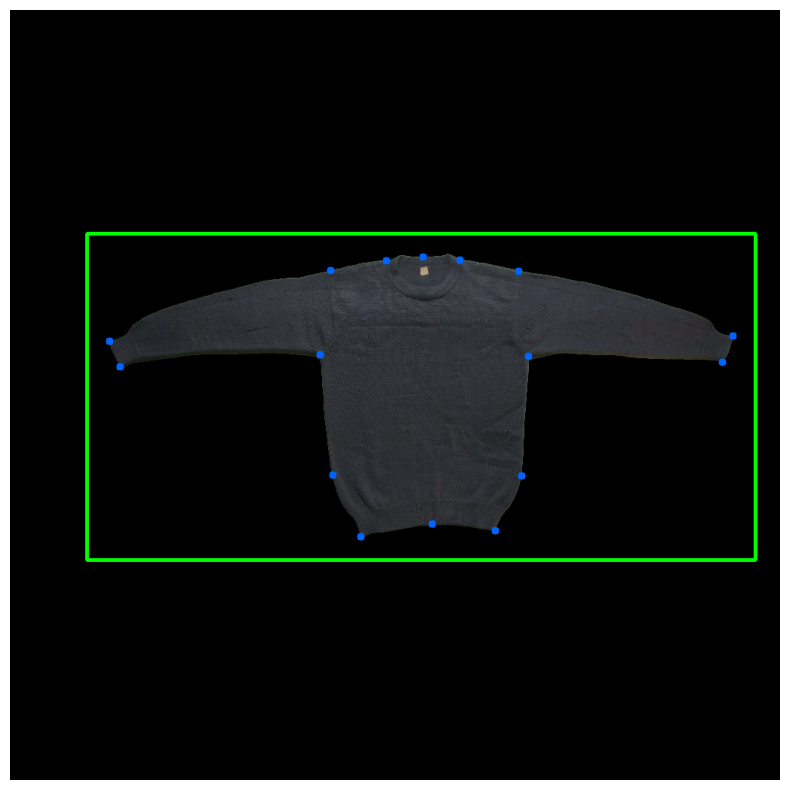

In [18]:
import os
import cv2
import matplotlib.pyplot as plt

# 1. Configuración de rutas (Asegúrate de que coincidan con tus carpetas reales)
BASE_PATH = r'C:\Users\USER\Desktop\clothes-failures-detection'
TARGET_SIZE = 1024
imagen = 'tmp22r0yzb5_jpg.rf.a9db78d861a4ddf0b23d5fd1680f19b9'

# Ajusta estas carpetas según lo que veas en tu escritorio
# Si BiRefNet las guardó directamente en 'valid_1024', usa esa
img_path = os.path.join(BASE_PATH, f"valid_{TARGET_SIZE}", "images", f"{imagen}.jpg")
label_path = os.path.join(BASE_PATH, f"valid_{TARGET_SIZE}", "labels", f"{imagen}.txt")

def verify_alignment_with_bbox(img_p, lbl_p):
    # VERIFICACIÓN DE EXISTENCIA
    if not os.path.exists(img_p):
        print(f"❌ ERROR: No se encuentra la IMAGEN en: {img_p}")
        return
    if not os.path.exists(lbl_p):
        print(f"❌ ERROR: No se encuentra el LABEL en: {lbl_p}")
        return

    # Leer imagen
    img = cv2.imread(img_p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = img.shape

    with open(lbl_p, 'r') as f:
        line = f.readline().split()
        if not line: 
            print("El archivo de etiqueta está vacío")
            return

        # Dibujar BBox
        xc, yc, w, h = float(line[1]), float(line[2]), float(line[3]), float(line[4])
        x1 = int((xc - w/2) * w_img)
        y1 = int((yc - h/2) * h_img)
        x2 = int((xc + w/2) * w_img)
        y2 = int((yc + h/2) * h_img)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        
        # Dibujar Keypoints
        for i in range(5, len(line), 3):
            px = float(line[i]) * w_img
            py = float(line[i+1]) * h_img
            cv2.circle(img, (int(px), int(py)), 5, (0, 100, 255), -1)

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Ejecutar
verify_alignment_with_bbox(img_path, label_path)

# Aumento de data

In [21]:
import albumentations as A
import cv2
import os
import numpy as np
BASE_PATH = r'C:\Users\USER\Desktop\clothes-failures-detection'

INPUT_IMG_AUG = os.path.join(BASE_PATH, f"train_{TARGET_SIZE}", "images")
INPUT_LBL_AUG = os.path.join(BASE_PATH, f"train_{TARGET_SIZE}", "labels")
OUTPUT_IMG_AUG = os.path.join(BASE_PATH, f"train_aug", "images")
OUTPUT_LBL_AUG = os.path.join(BASE_PATH, f"train_aug", "labels")

# 1. Definir el Pipeline (Seguro para Metrología)
transform = A.Compose([
    #A.HorizontalFlip(p=0.5),
    # Bajamos un poco el contraste para no "quemar" los bordes
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.4),
    A.Rotate(
        limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        fill_value=0,
        interpolation=cv2.INTER_LANCZOS4, # CRÍTICO: Mantiene el borde nítido
        p=0.5
    ),
    # GaussNoise casi imperceptible para no deformar el borde
    A.GaussNoise(std_range=(0.01, 0.02), p=0.2),
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

def augment_dataset(img_dir, label_dir, output_img_dir, output_label_dir, n_variants=5):
    if not os.path.exists(output_img_dir): os.makedirs(output_img_dir)
    if not os.path.exists(output_label_dir): os.makedirs(output_label_dir)

    img_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]

    print(f"Iniciando aumento de {len(img_files)} imágenes...")

    for img_name in img_files:
        # Cargar imagen
        img_path = os.path.join(img_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape

        # Cargar etiquetas (Keypoints)
        label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + ".txt")
        if not os.path.exists(label_path): continue

        with open(label_path, 'r') as f:
            line = f.readline().split()
            class_id = line[0]
            # Extraer solo x, y de los keypoints (ignorando visibilidad temporalmente)
            kpts = []
            visibilities = []
            for i in range(5, len(line), 3):
                kpts.append([float(line[i]) * w, float(line[i+1]) * h])
                visibilities.append(line[i+2])

        # Generar variantes
        for v in range(n_variants):
            transformed = transform(image=image, keypoints=kpts)
            t_image = transformed['image']
            t_kpts = transformed['keypoints']

            # Nombre de archivo único
            new_name = f"aug_{v}_{img_name}"

            # Guardar Imagen
            cv2.imwrite(os.path.join(output_img_dir, new_name), cv2.cvtColor(t_image, cv2.COLOR_RGB2BGR))

            # Guardar Label (con el BBox recalculado para la nueva posición)
            t_kpts_np = np.array(t_kpts)
            # Normalizar de nuevo
            t_kpts_norm = t_kpts_np / [w, h]

            # Recalcular BBox dinámico para la variante aumentada
            x_min, y_min = np.min(t_kpts_norm, axis=0)
            x_max, y_max = np.max(t_kpts_norm, axis=0)

            margin = 0.03
            bx1, by1 = max(0, x_min - margin), max(0, y_min - margin)
            bx2, by2 = min(1, x_max + margin), min(1, y_max + margin)

            bw, bh = bx2 - bx1, by2 - by1
            bcx, bcy = bx1 + bw/2, by1 + bh/2

            # Formatear línea final
            new_parts = [class_id, f"{bcx:.6f}", f"{bcy:.6f}", f"{bw:.6f}", f"{bh:.6f}"]
            for i, (kx, ky) in enumerate(t_kpts_norm):
                new_parts.extend([f"{kx:.6f}", f"{ky:.6f}", visibilities[i]])

            with open(os.path.join(output_label_dir, os.path.splitext(new_name)[0] + ".txt"), 'w') as f:
                f.write(" ".join(new_parts))

    print(f"¡Hecho! Dataset multiplicado. Ahora tienes aproximadamente {len(img_files) * n_variants} imágenes.")

# Ejecutar (Aumentar x5)
augment_dataset(INPUT_IMG_AUG, INPUT_LBL_AUG, OUTPUT_IMG_AUG, OUTPUT_LBL_AUG, n_variants=5)

Error fetching version info <urlopen error _ssl.c:993: The handshake operation timed out>
Argument(s) 'fill_value' are not valid for transform Rotate


Iniciando aumento de 40 imágenes...
¡Hecho! Dataset multiplicado. Ahora tienes aproximadamente 200 imágenes.


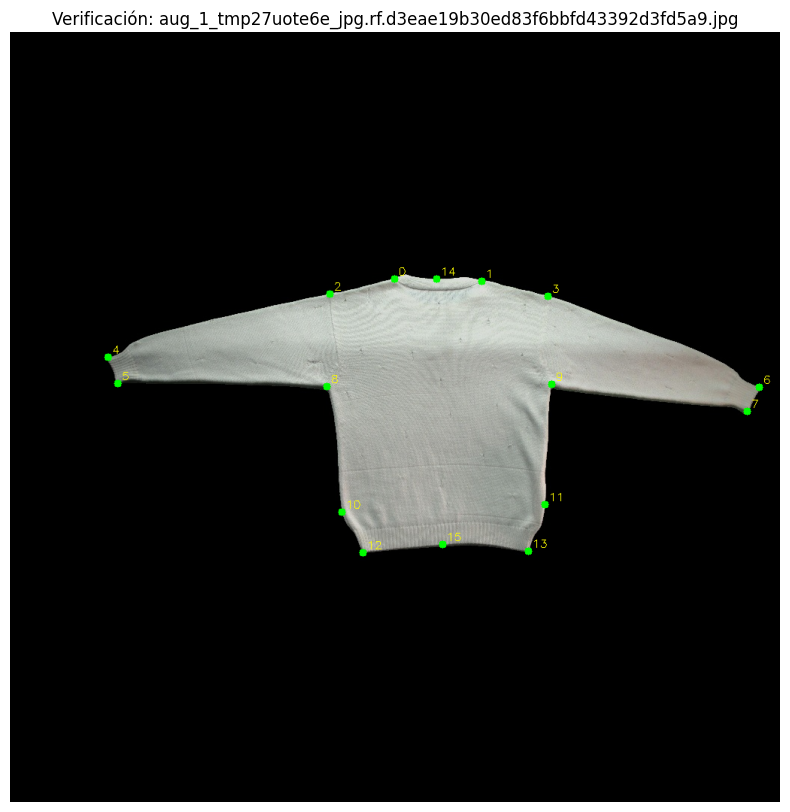

In [3]:
import cv2
import matplotlib.pyplot as plt
import os
import random

BASE_PATH = r'C:\Users\USER\Desktop\clothes-failures-detection'
TARGET_SIZE = 1024

INPUT_IMG_AUG = os.path.join(BASE_PATH, f"train_{TARGET_SIZE}", "images")
INPUT_LBL_AUG = os.path.join(BASE_PATH, f"train_{TARGET_SIZE}", "labels")
OUTPUT_IMG_AUG = os.path.join(BASE_PATH, f"train_aug", "images")
OUTPUT_LBL_AUG = os.path.join(BASE_PATH, f"train_aug", "labels")


def verificar_aumento(img_dir, label_dir):
    # Seleccionar una imagen al azar de las aumentadas
    img_name = random.choice(os.listdir(img_dir))
    img_path = os.path.join(img_dir, img_name)
    label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + ".txt")

    # Leer imagen
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    # Leer etiquetas
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.split()
            # Los keypoints empiezan en el índice 5 (después de class, cx, cy, w, h)
            kpts = parts[5:]

            for i in range(0, len(kpts), 3):
                kx = float(kpts[i]) * w
                ky = float(kpts[i+1]) * h
                # Dibujar punto y número para verificar el orden
                cv2.circle(image, (int(kx), int(ky)), 5, (0, 255, 0), -1)
                cv2.putText(image, str(i//3), (int(kx)+5, int(ky)-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.title(f"Verificación: {img_name}")
    plt.axis('off')
    plt.show()

# Ejecutar verificación
verificar_aumento(OUTPUT_IMG_AUG, OUTPUT_LBL_AUG)

# Generar data.yaml

In [6]:
import yaml
import os

BASE_PATH = r'C:\Users\USER\Desktop\clothes-failures-detection'
TARGET_SIZE = 1024

# Corregimos los nombres de las rutas para el YAML
# YOLO usa la ruta 'path' como raíz y luego concatena 'train' y 'val'
# Es mejor usar rutas relativas dentro del YAML o la ruta absoluta completa.

# Mapa de simetría (se mantiene igual)
flip_idx = [1, 0, 3, 2, 6, 7, 4, 5, 9, 8, 11, 10, 13, 12, 14, 15]

data_config = {
    # 'path' debe ser la carpeta raíz de tu proyecto
    'path': BASE_PATH, 
    
    # Rutas relativas desde 'path'
    'train': 'train_aug/images',
    'val': f'valid_{TARGET_SIZE}/images',
    
    'nc': 1,
    'names': {0: 'chompa'}, # Formato diccionario es más robusto para YOLO
    
    # Keypoints: 16 puntos, cada uno con [x, y, v]
    'kpt_shape': [16, 3], 
    
    # Mapa de simetría para aumentación automática durante entrenamiento
    'flip_idx': flip_idx
}

# Guardar el archivo en la raíz del proyecto
yaml_path = os.path.join(BASE_PATH, 'chompa_pose.yaml')

with open(yaml_path, 'w') as f:
    # default_flow_style=False genera un YAML legible (vertical)
    # sort_keys=False mantiene el orden que definimos
    yaml.dump(data_config, f, default_flow_style=False, sort_keys=False)

print(f"✅ 'chompa_pose.yaml' creado en: {yaml_path}")
print(f"--- Configuración local de Windows lista ---")

✅ 'chompa_pose.yaml' creado en: C:\Users\USER\Desktop\clothes-failures-detection\chompa_pose.yaml
--- Configuración local de Windows lista ---


# Transfer Learning

In [52]:
print('Listo para entrenamiento Vs10')

Listo para entrenamiento Vs10


## Version 6

In [ ]:
import torch
from ultralytics import YOLO

torch.cuda.empty_cache()

# 1. Cargamos el modelo SMALL
model = YOLO('yolo11s-pose.pt')

# 2. Entrenamiento v6 (Estrategia de Precisión Extrema)
results = model.train(
    data='chompa_pose.yaml',
    imgsz=1024,                   # 1. CAMBIO: Subimos a 1024 para aprovechar tu nuevo pre-procesamiento
    epochs=150,
    batch=8,                      # Si da error de memoria a 1024px, baja a 4 o 6

    # --- PESOS DE PRECISIÓN (CIRUGÍA PARA PUÑOS) ---
    lr0=0.001,
    pose=50.0,                    # 2. CAMBIO: Doblamos la importancia (de 25 a 50). Prioridad total a la ubicación del punto.
    kobj=15.0,                    # 3. CAMBIO: Triplicamos (de 5 a 15). Castigo severo si el punto desaparece.
    label_smoothing=0.05,         # 4. CAMBIO: Menos suavizado para que sea más estricto con el borde real.

    # --- LIMPIEZA VISUAL (CRÍTICO) ---
    fliplr=0.5,
    mosaic=0.0,                   # 5. CAMBIO: Desactivamos Mosaic. Evita que la imagen se corte y el modelo pierda los puños.

    # --- CONFIGURACIÓN ---
    patience=50,                  # Le damos un poco más de margen para que aprenda el ajuste fino
    project='metrologia_chompas',
    name='v6_small_1024',
    device=0,
    plots=True
)

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=chompa_pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=15.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-pose.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=v6_small_1024, nbs=64, nms=False, opset=None

## Version 7

In [11]:
import torch
from ultralytics import YOLO
import os
import gc

# 1. LIMPIEZA AGRESIVA DE MEMORIA
def clear_gpu():
    torch.cuda.empty_cache()
    gc.collect()
    # Forzar a Windows a liberar segmentos expandibles
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

clear_gpu()

# 1. Cargamos el modelo MEDIUM
model = YOLO('yolo11m-pose.pt')

# 2. Entrenamiento v6 (Estrategia de Precisión Extrema)
results = model.train(
    data='chompa_pose.yaml',
    imgsz=1024,                   # 1. CAMBIO: Subimos a 1024 para aprovechar tu nuevo pre-procesamiento
    epochs=150,
    batch=4,                      # Si da error de memoria a 1024px, baja a 4 o 6

    # --- AJUSTES ANTI-MEMORIA (WINDOWS) ---
    workers=0,            # CRÍTICO: Evita el AcceleratorError en Windows
    cache=False,          # No guardamos nada extra en VRAM

    # --- PESOS DE PRECISIÓN (CIRUGÍA PARA PUÑOS) ---
    lr0=0.001,
    pose=100.0,                    # 2. CAMBIO: Doblamos la importancia (de 25 a 50). Prioridad total a la ubicación del punto.
    kobj=20.0,                    # 3. CAMBIO: Triplicamos (de 5 a 15). Castigo severo si el punto desaparece.
    label_smoothing=0.05,         # 4. CAMBIO: Menos suavizado para que sea más estricto con el borde real.

    # --- LIMPIEZA VISUAL (CRÍTICO) ---
    fliplr=0.5,
    mosaic=0.0,                   # 5. CAMBIO: Desactivamos Mosaic. Evita que la imagen se corte y el modelo pierda los puños.
    hsv_v=0.8,

    # --- CONFIGURACIÓN ---
    patience=50,                  # Le damos un poco más de margen para que aprenda el ajuste fino
    project='metrologia_chompas',
    name='v7_medium_1024',
    device=0,
    plots=True
)

New https://pypi.org/project/ultralytics/8.4.14 available  Update with 'pip install -U ultralytics'
WARNING 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.241  Python-3.12.12 torch-2.12.0.dev20260220+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=chompa_pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.8, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=20.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-pose.

## Version8

In [15]:
import torch
from ultralytics import YOLO
import os
import gc

# 1. LIMPIEZA AGRESIVA DE MEMORIA
def clear_gpu():
    torch.cuda.empty_cache()
    gc.collect()
    # Forzar a Windows a liberar segmentos expandibles
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

clear_gpu()

# 1. CARGAMOS TU MODELO V7 (No el base de Ultralytics)
model = YOLO(r'C:\Users\USER\Desktop\clothes-failures-detection\metrologia_chompas\v7_medium_10245\weights\best.pt')

# 2. Entrenamiento v8 (Enfoque: Corrección de Bordes)
results = model.train(
    data='chompa_pose.yaml',
    imgsz=1024,
    epochs=100,           # Menos épocas porque ya sabe mucho
    batch=4,              # Mantenemos 4 para el modelo Medium

    # --- AJUSTES ANTI-MEMORIA (WINDOWS) ---
    workers=0,            # CRÍTICO: Evita el AcceleratorError en Windows
    cache=False,          # No guardamos nada extra en VRAM

    # --- PESOS DE "SUCCIÓN" HACIA EL BORDE ---
    lr0=0.0005,           # Bajamos la tasa de aprendizaje para que el ajuste sea suave y no rompa el v7
    pose=150.0,           # Subimos a 150 para forzar el anclaje al borde
    kobj=30.0,            # Penalización alta por no detectar el keypoint exacto
    label_smoothing=0.0,  # Eliminamos suavizado para buscar el píxel final del borde

    # --- RELEVANCIA VISUAL ---
    hsv_v=0.4,            # Forzamos brillo alto para que el modelo "vea" la lana contra el fondo
    hsv_s=0.015,            # Saturamos colores para resaltar texturas

    # --- LIMPIEZA ---
    mosaic=0.0,
    close_mosaic=0,
    fliplr=0.5,
    patience=30,          # Si no mejora en 30 épocas, se detiene
    project='metrologia_chompas',
    name='v8_medium_1024',
    device=0,
    plots=True
)

WARNING 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.241  Python-3.12.12 torch-2.12.0.dev20260220+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=chompa_pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.015, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=30.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Users\USER\Desktop\clothes-failures-detection\metrologia_chompas\v7_medium_10245\weights\best.pt, momentum=0

## Version10

In [16]:
import torch
from ultralytics import YOLO
import os
import gc

# 1. LIMPIEZA AGRESIVA DE MEMORIA
def clear_gpu():
    torch.cuda.empty_cache()
    gc.collect()
    # Forzar a Windows a liberar segmentos expandibles
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

clear_gpu()

# 1. CARGAMOS TU MEJOR MODELO HASTA AHORA (V8)
model = YOLO(r'C:\Users\USER\Desktop\clothes-failures-detection\metrologia_chompas\v8_medium_1024\weights\best.pt')

results = model.train(
    data='chompa_pose.yaml',
    imgsz=1024,                   # Volvemos a 1024 (más estable para el modelo Medium)
    epochs=100,
    batch=4,                      # Subimos el batch para estabilizar gradientes

    # --- AJUSTES ANTI-MEMORIA (WINDOWS) ---
    workers=0,            # CRÍTICO: Evita el AcceleratorError en Windows
    cache=False,          # No guardamos nada extra en VRAM

    # --- EL "SECRETO" PARA LOS PUÑOS ---
    lr0=0.0001,                   # Tasa MUY BAJA para no romper lo que ya sabe
    hsv_v=0.6,          # Subimos un poco el factor de brillo/valor
    hsv_s=0.6,          # Saturación para resaltar texturas

    # --- ANCLAJE EXTREMO ---
    pose=150.0,
    kobj=20.0,
    overlap_mask=False,           # Evita que los bordes se suavicen con el fondo

    # --- CONFIGURACIÓN ---
    mosaic=0.0,
    name='v10_medium_1024',
    device=0
)

New https://pypi.org/project/ultralytics/8.4.14 available  Update with 'pip install -U ultralytics'


SyntaxError: '[31m[1mcontrast[0m' is not a valid YOLO argument. 

    Arguments received: ['yolo', '-f', 'C:\\Users\\USER\\AppData\\Roaming\\jupyter\\runtime\\kernel-e9c6a5eb-019d-46b6-aa3a-9b18b0e3ff8a.json']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of ['obb', 'detect', 'pose', 'segment', 'classify']
                MODE (required) is one of ['export', 'train', 'track', 'val', 'benchmark', 'predict']
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' that override defaults.
                    See all ARGS at https://docs.ultralytics.com/usage/cfg or with 'yolo cfg'

    1. Train a detection model for 10 epochs with an initial learning_rate of 0.01
        yolo train data=coco8.yaml model=yolo11n.pt epochs=10 lr0=0.01

    2. Predict a YouTube video using a pretrained segmentation model at image size 320:
        yolo predict model=yolo11n-seg.pt source='https

# Validaciones

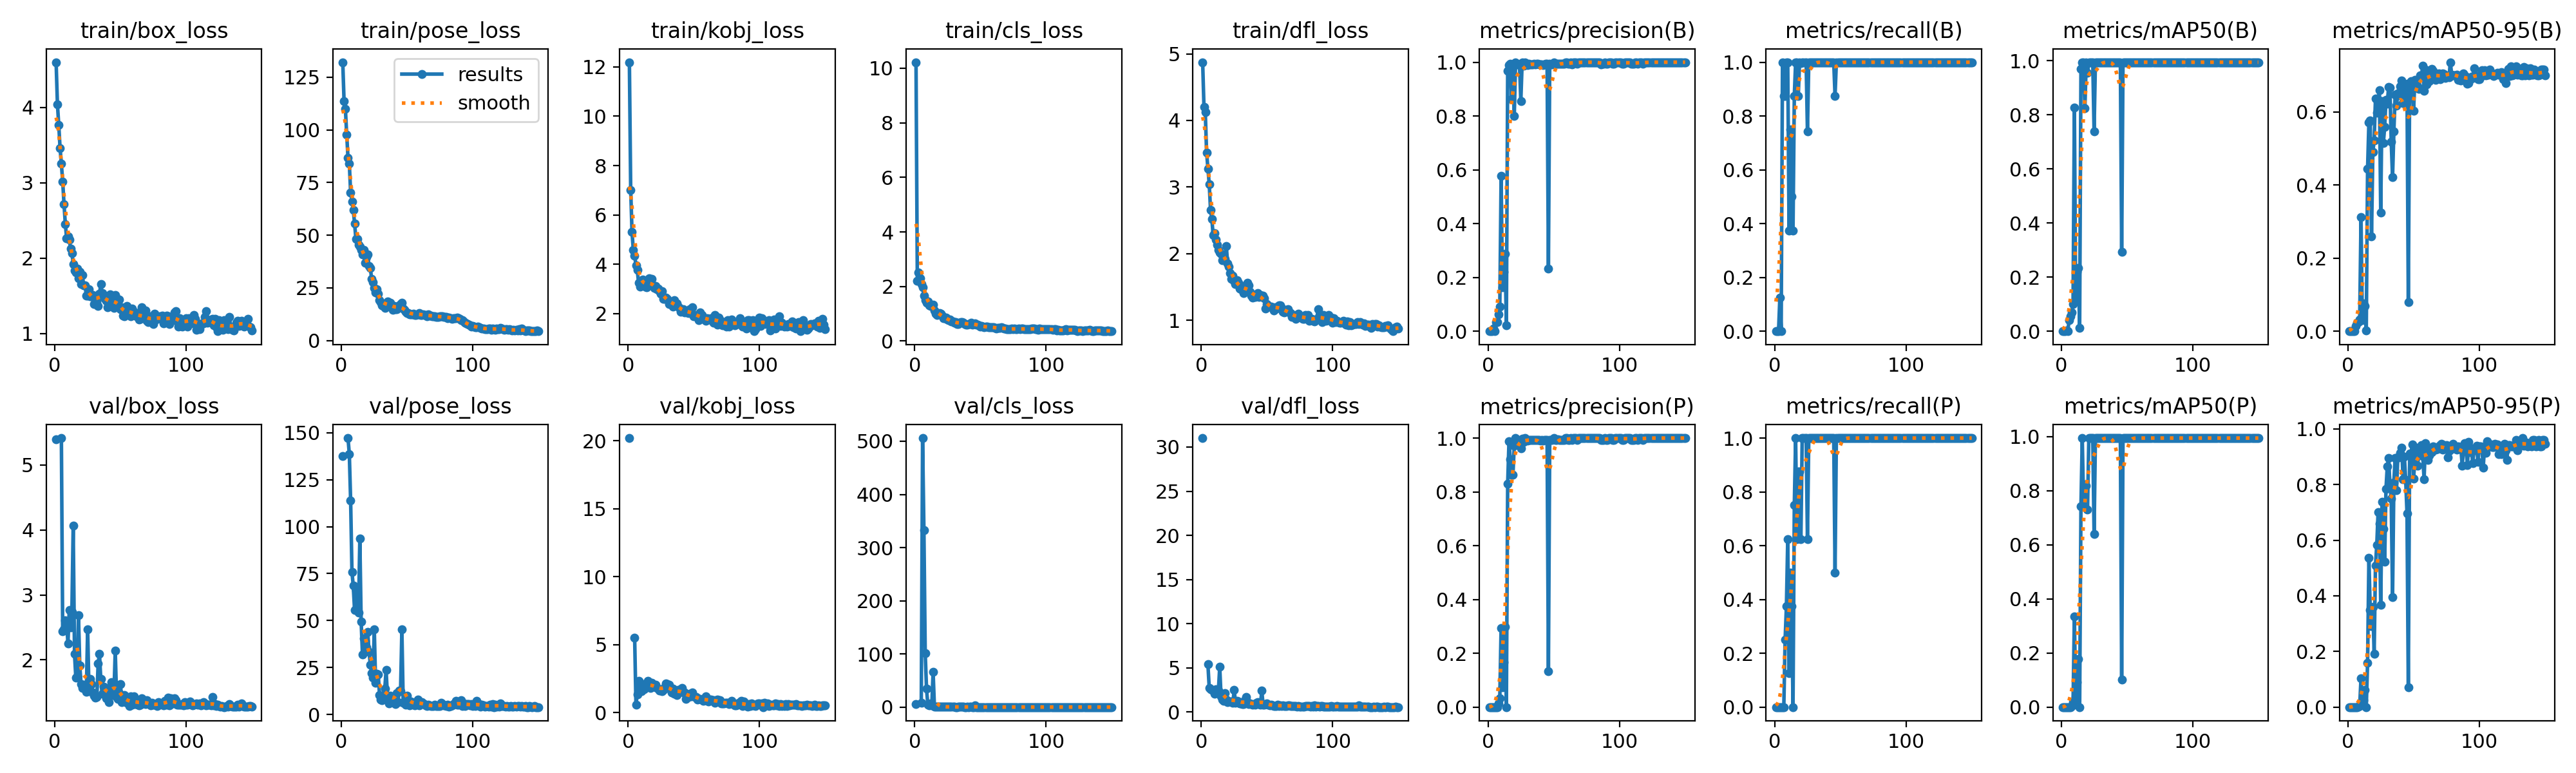

In [20]:
from IPython.display import Image
import os
modelo = 'v10_medium_1024'
# Ruta automática basada en el nombre que le dimos al entrenamiento
path_resultados = f'/content/runs/pose/metrologia_chompas/{modelo}/results.png'

if os.path.exists(path_resultados):
    display(Image(filename=path_resultados, width=800))
else:
    print("El archivo aún no se ha generado. Espera a que termine al menos la primera época.")

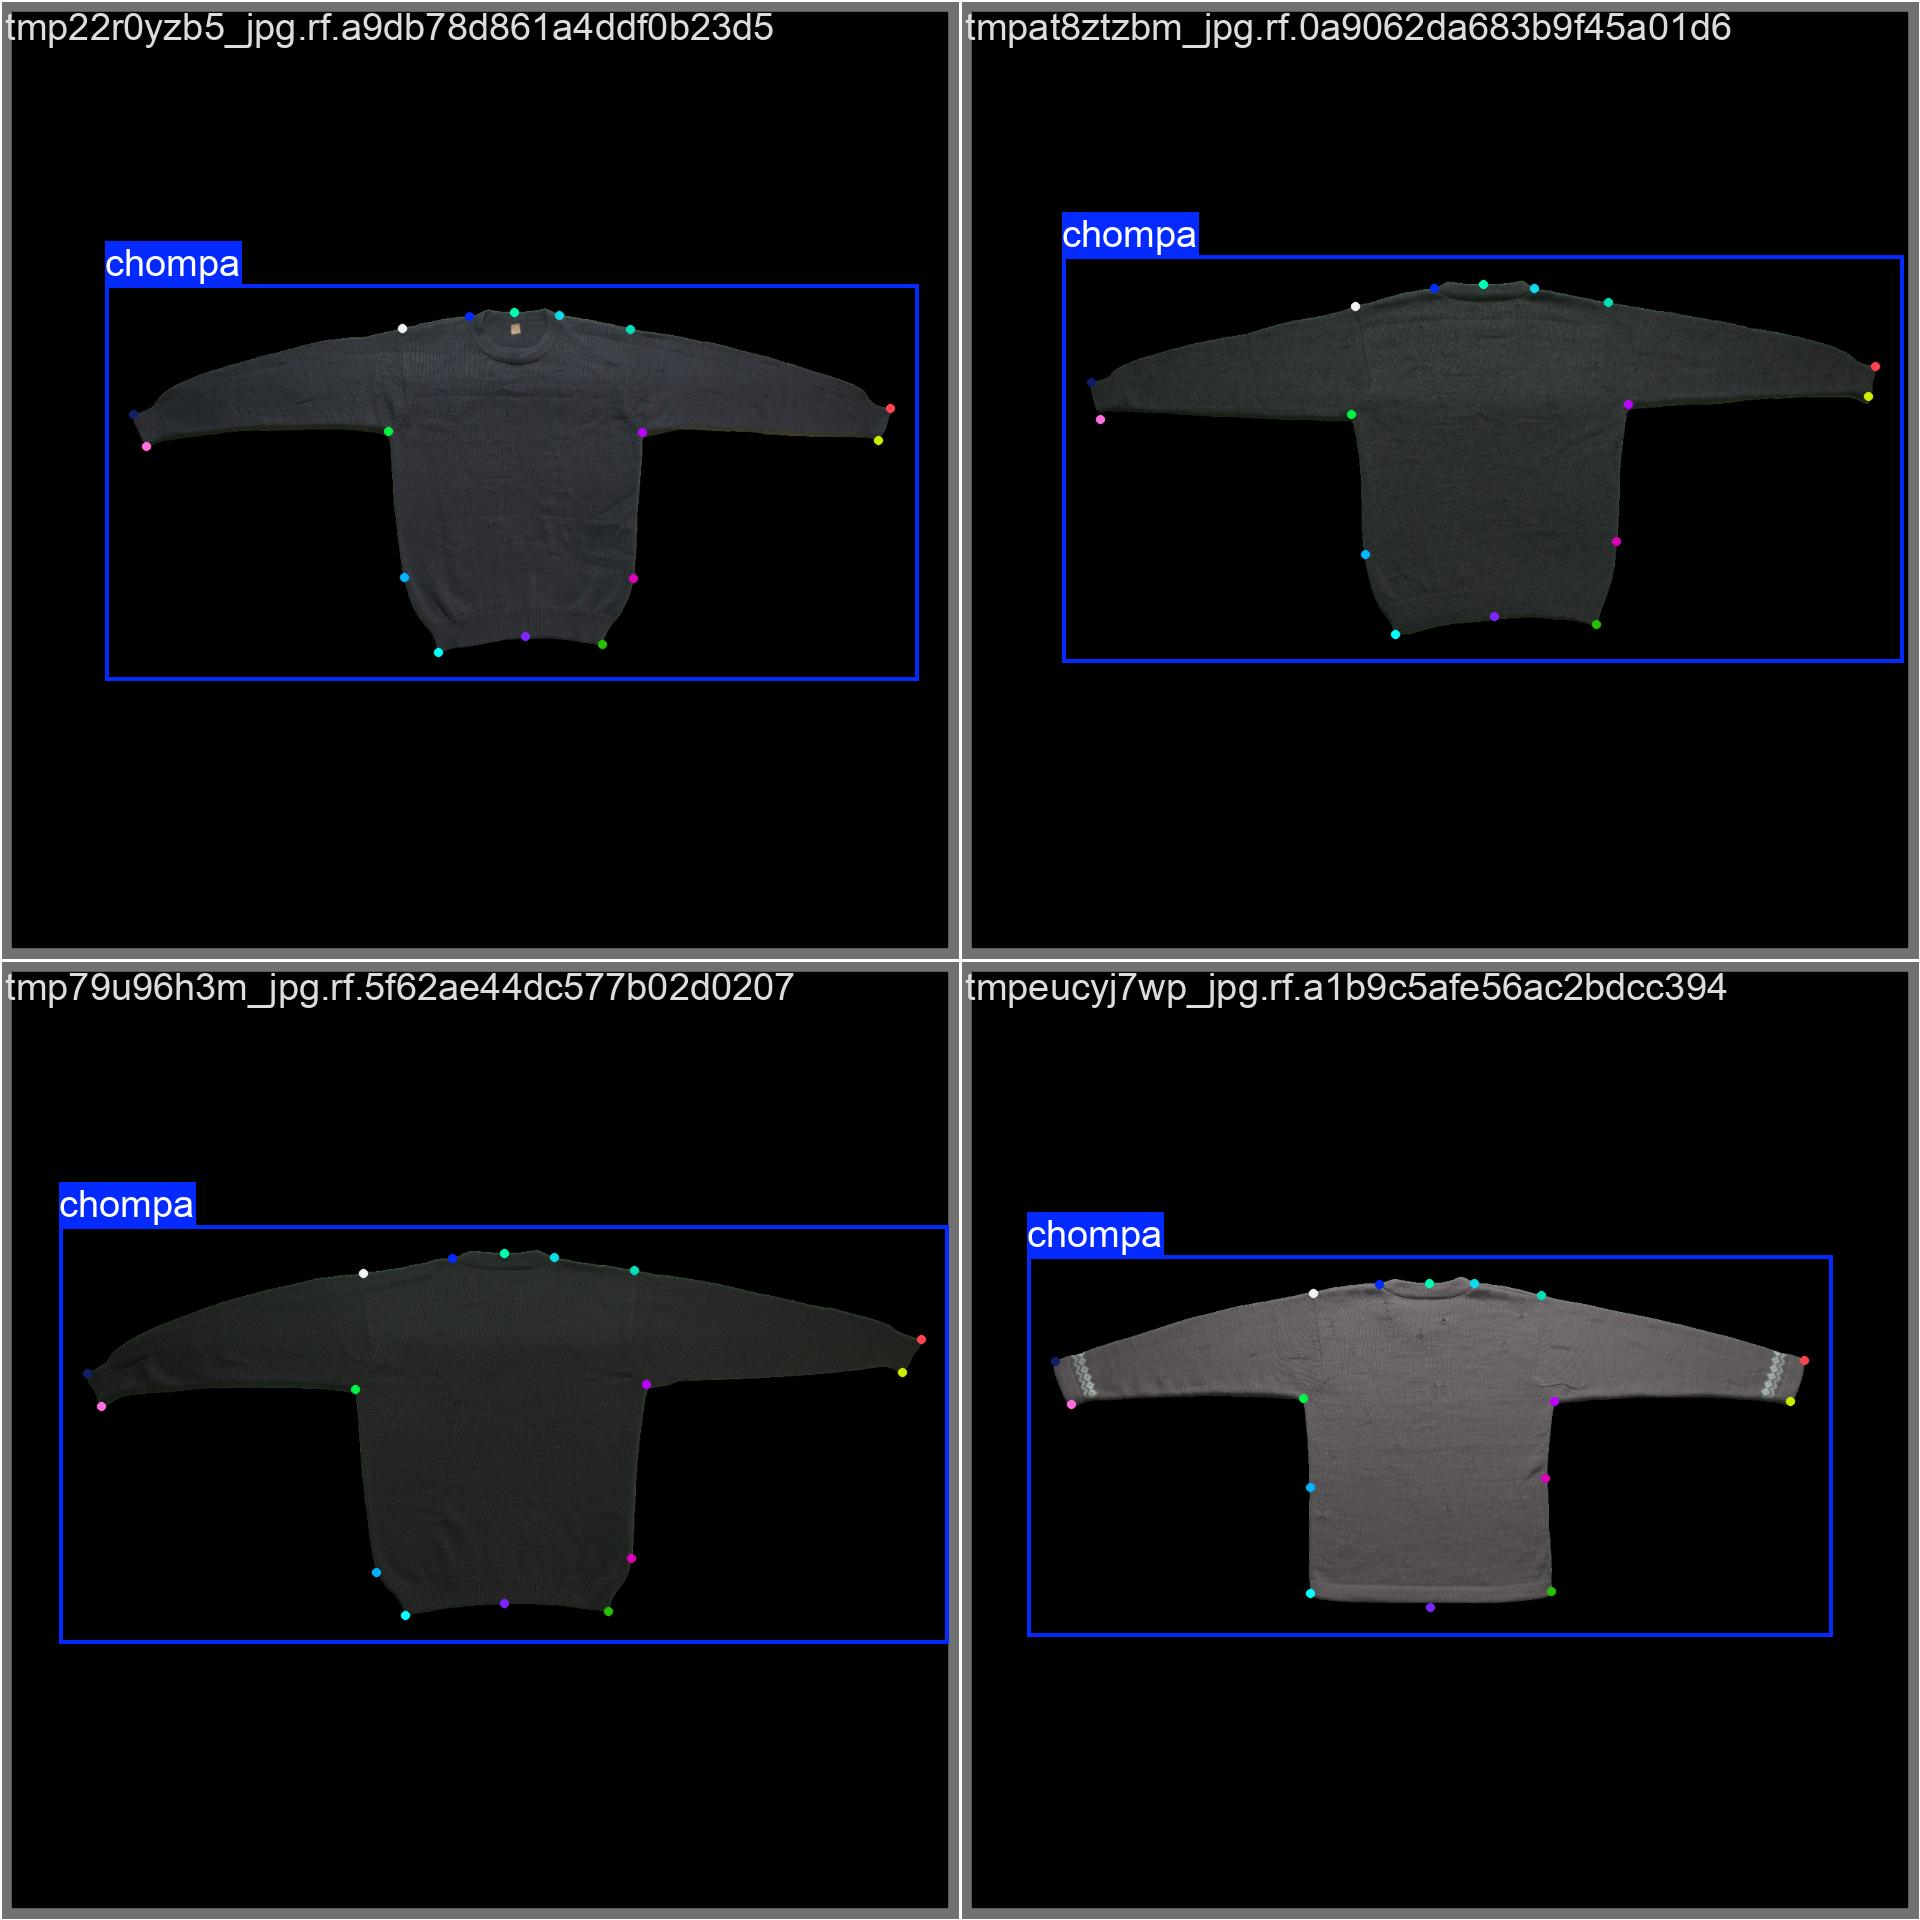

In [21]:
from IPython.display import Image
import os

# Ruta automática basada en el nombre que le dimos al entrenamiento
path_resultados = f'/content/runs/pose/metrologia_chompas/{modelo}/val_batch0_labels.jpg'

if os.path.exists(path_resultados):
    display(Image(filename=path_resultados, width=800))
else:
    print("El archivo aún no se ha generado. Espera a que termine al menos la primera época.")

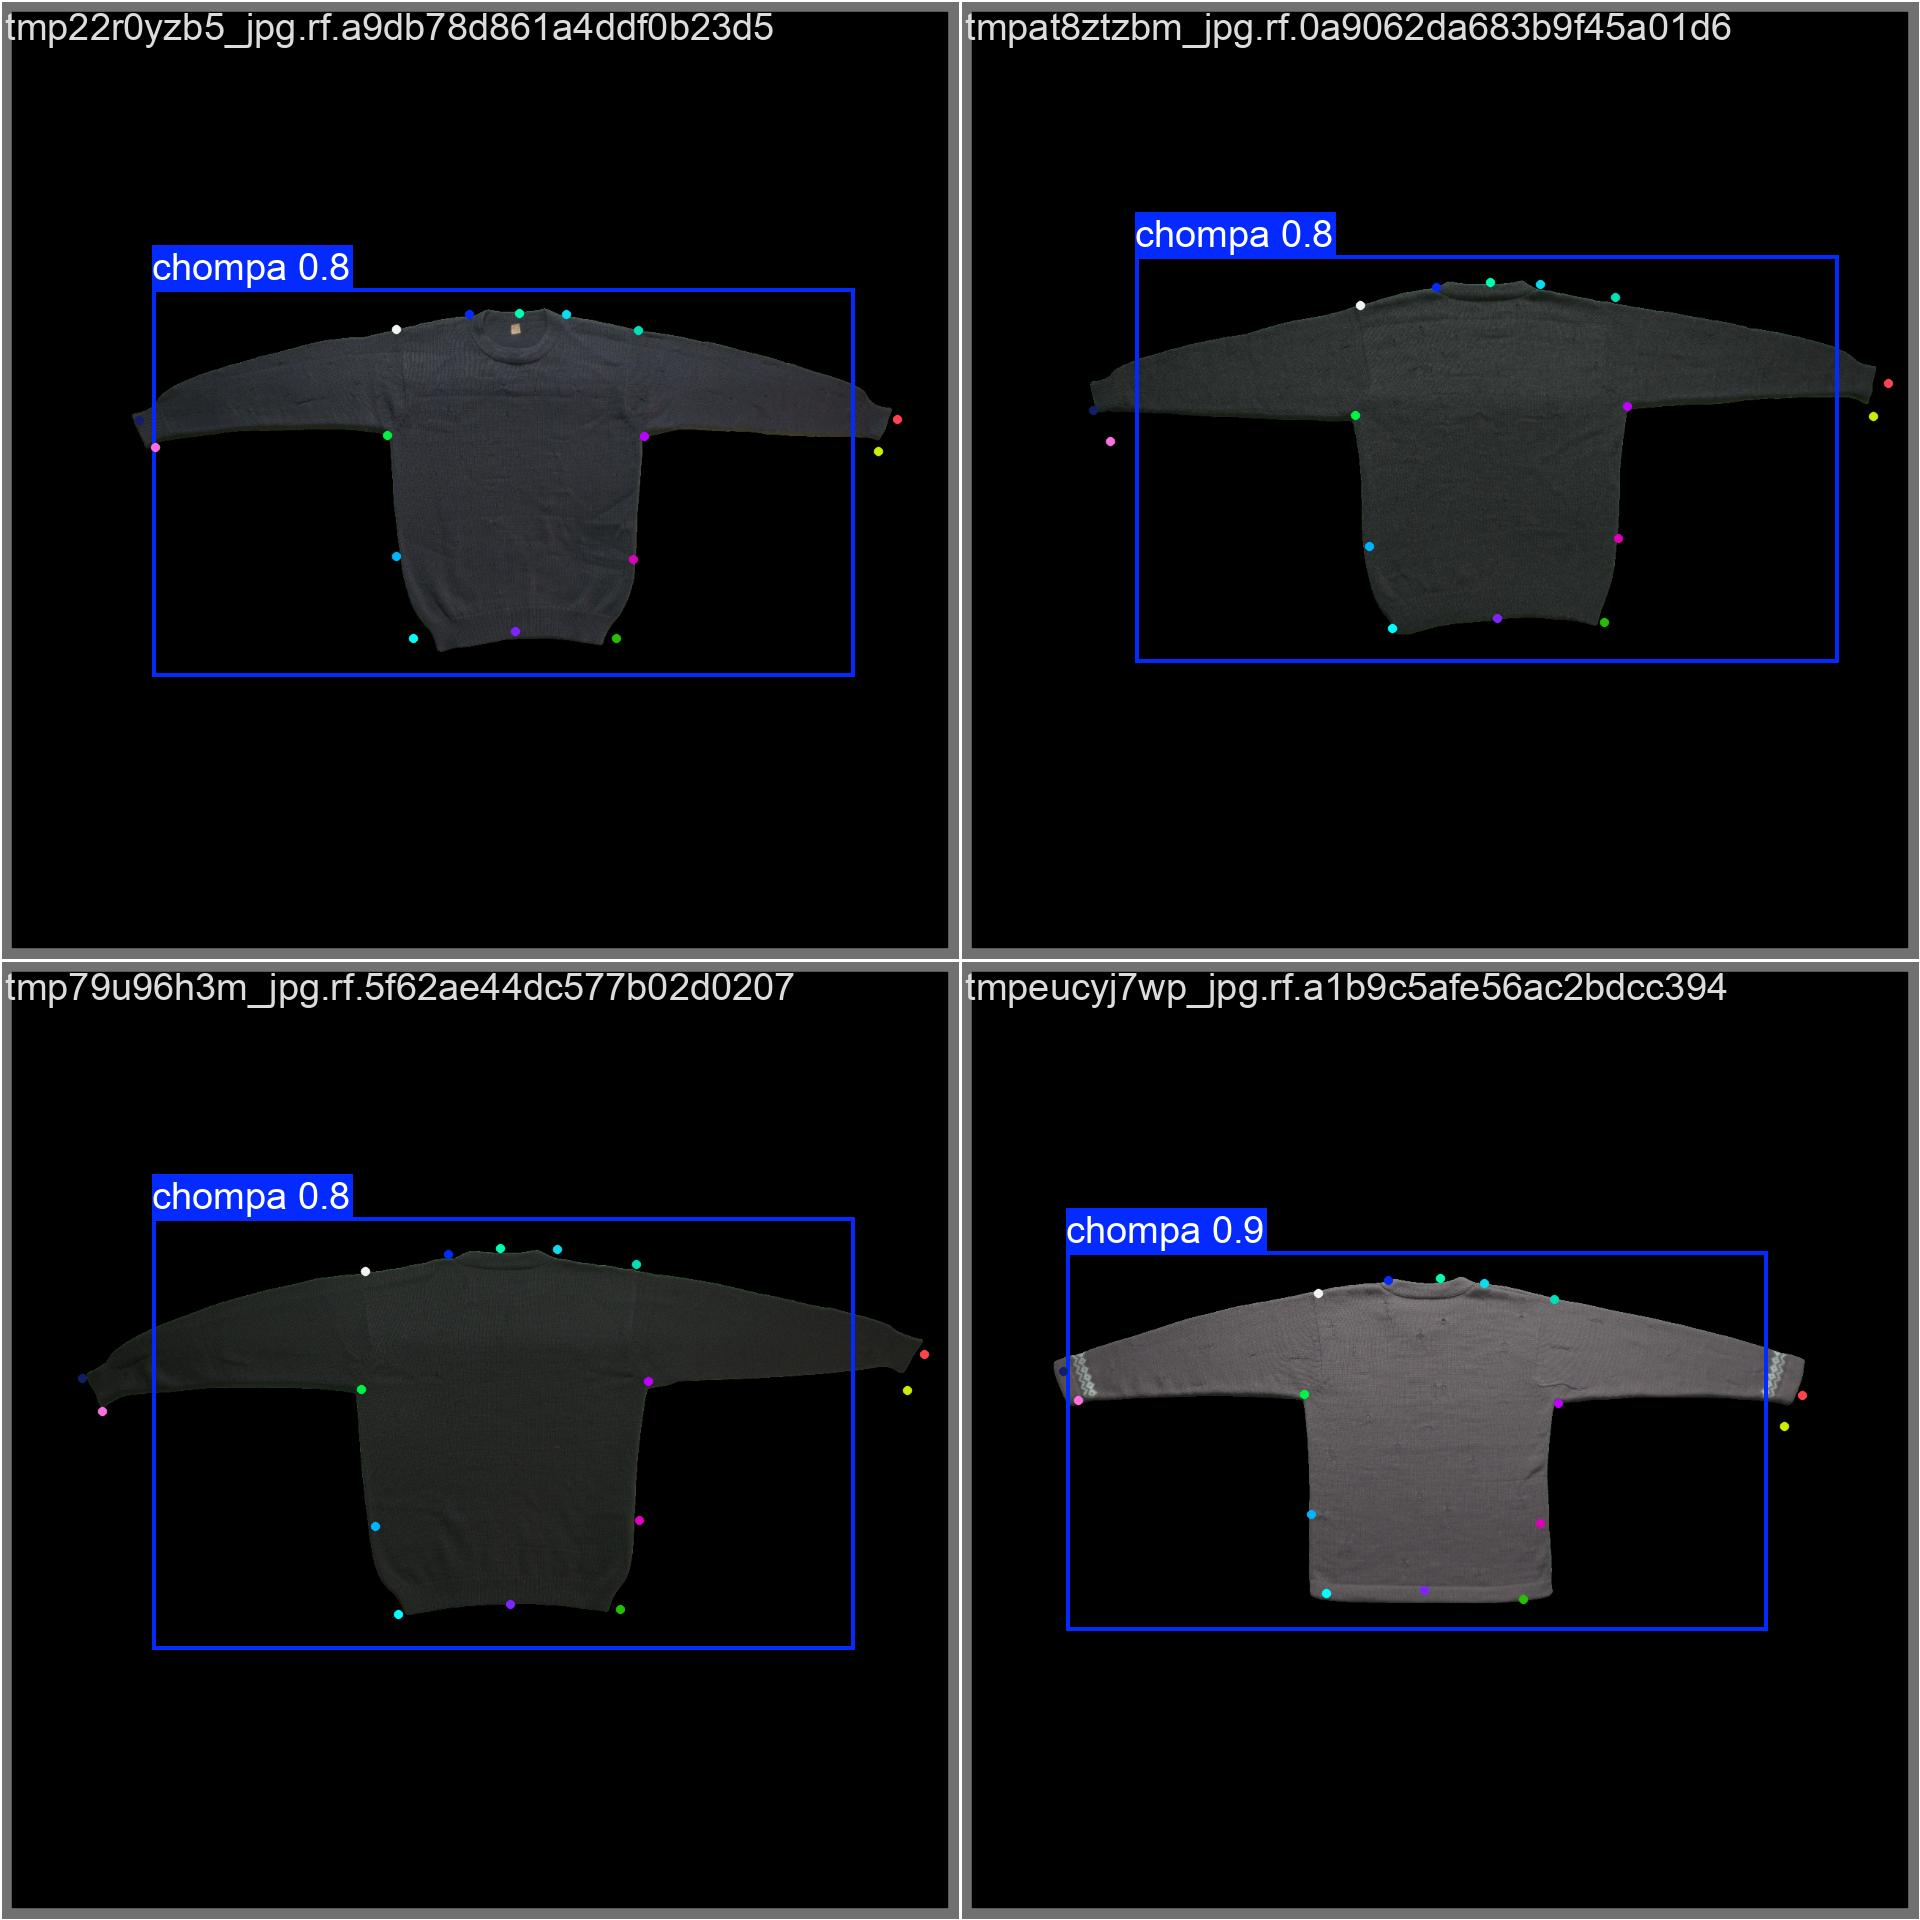

In [22]:
from IPython.display import Image
import os

# Ruta automática basada en el nombre que le dimos al entrenamiento
path_resultados = f'/content/runs/pose/metrologia_chompas/{modelo}/val_batch0_pred.jpg'

if os.path.exists(path_resultados):
    display(Image(filename=path_resultados, width=800))
else:
    print("El archivo aún no se ha generado. Espera a que termine al menos la primera época.")

In [23]:
import pandas as pd

# Cambia la ruta por la carpeta de tu mejor modelo
path_results = f'/content/runs/pose/metrologia_chompas/{modelo}/results.csv'
df = pd.read_csv(path_results)

# Limpiar espacios en los nombres de las columnas
df.columns = df.columns.str.strip()

# Obtener la última fila
final_metrics = df.iloc[-1]

print(f"📊 mAP50-95 (Pose): {final_metrics['metrics/mAP50-95(P)']: .4f}")
print(f"📊 mAP50 (Pose):    {final_metrics['metrics/mAP50(P)']: .4f}")

📊 mAP50-95 (Pose):  0.9463
📊 mAP50 (Pose):     0.9950



image 1/1 /content/valid_1280/images/tmp22r0yzb5_jpg.rf.a9db78d861a4ddf0b23d5fd1680f19b9.jpg: 1024x1024 1 chompa, 86.6ms
Speed: 8.1ms preprocess, 86.6ms inference, 1.5ms postprocess per image at shape (1, 3, 1024, 1024)
--- Análisis de Keypoints para: /content/valid_1280/images/tmp22r0yzb5_jpg.rf.a9db78d861a4ddf0b23d5fd1680f19b9.jpg ---
Punto 0: Coords(626, 415) - Confianza: 0.9999
Punto 1: Coords(764, 416) - Confianza: 0.9999
Punto 2: Coords(527, 434) - Confianza: 0.9994
Punto 3: Coords(861, 435) - Confianza: 0.9997
Punto 4: Coords(171, 550) - Confianza: 0.9782
Punto 5: Coords(193, 588) - Confianza: 0.9805
Punto 6: Coords(1214, 564) - Confianza: 0.9722
Punto 7: Coords(1191, 612) - Confianza: 0.9808
Punto 8: Coords(511, 578) - Confianza: 1.0000
Punto 9: Coords(870, 580) - Confianza: 0.9998
Punto 10: Coords(523, 745) - Confianza: 0.9997
Punto 11: Coords(848, 753) - Confianza: 0.9997
Punto 12: Coords(545, 859) - Confianza: 0.9999
Punto 13: Coords(825, 860) - Confianza: 0.9998
Punto 14: 

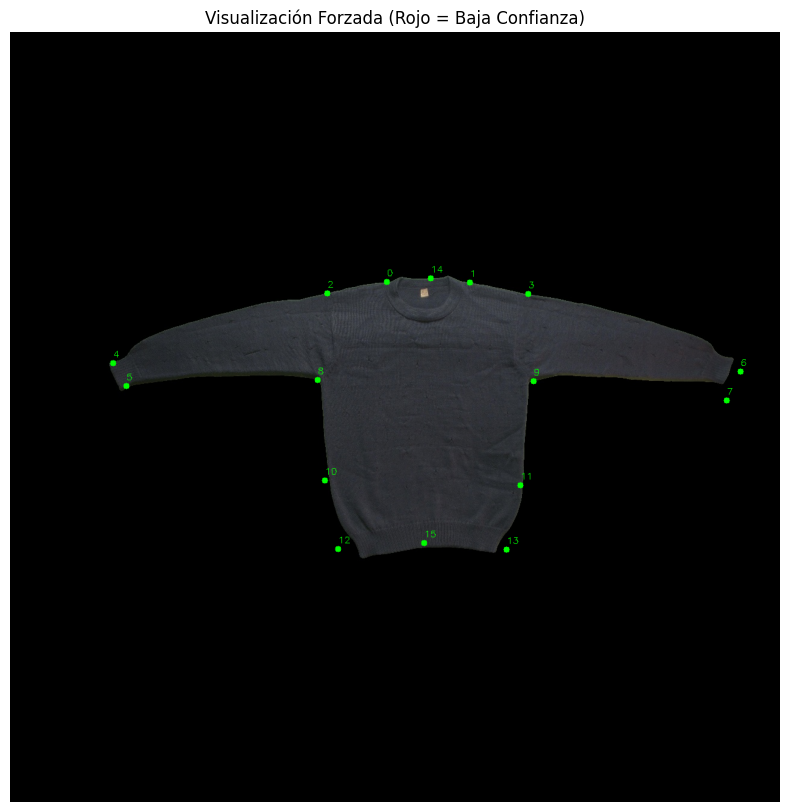

In [24]:
import cv2
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 1. Cargar tu mejor modelo
model = YOLO(f'/content/runs/pose/metrologia_chompas/{modelo}/weights/best.pt')

# 2. Ruta de la imagen que quieres inspeccionar
img_path = '/content/valid_1024/images/tmpat8ztzbm_jpg.rf.0a9062da683b9f45a01d62af8efb1a07.jpg'

# 3. Inferencia con umbral de confianza MUY BAJO (0.10)
# Esto nos mostrará si el modelo detectó los puños pero con baja seguridad.
results = model.predict(source=img_path, conf=0.10, imgsz=1024)

for r in results:
    img = r.orig_img.copy()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Extraer keypoints y sus confianzas
    # shape: [num_personas, num_keypoints, 3] -> (x, y, conf)
    kpts = r.keypoints.data[0].cpu().numpy()

    print(f"--- Análisis de Keypoints para: {img_path} ---")
    for i, kpt in enumerate(kpts):
        x, y, conf = kpt
        # Los puños suelen ser los últimos puntos según tu flip_idx (puntos 12, 13, 14, 15)
        print(f"Punto {i}: Coords({int(x)}, {int(y)}) - Confianza: {conf:.4f}")

        # Dibujar TODOS los puntos encontrados, incluso los de baja confianza
        color = (0, 255, 0) if conf > 0.5 else (255, 0, 0) # Verde si es bueno, Rojo si es dudoso
        cv2.circle(img, (int(x), int(y)), 5, color, -1)
        cv2.putText(img, str(i), (int(x), int(y)-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    plt.figure(figsize=(10,10))
    plt.imshow(img)
    plt.title("Visualización Forzada (Rojo = Baja Confianza)")
    plt.axis('off')
    plt.show()

# Exportar data de entrenamiento

In [ ]:
# 1. Comprimir la carpeta 'runs'
!zip -r resultados_yolo.zip runs/

# 2. Descargar el archivo a tu PC
from google.colab import files
files.download('resultados_yolo.zip')